In [2]:
import awkward as ak
import numpy as np
import torch
from torch import nn
import uproot
import matplotlib.pyplot as plt
import matplotlib.text

from atlasopenmagic import install_from_environment

import atlasopenmagic as atom
atom.set_release('2025e-13tev-beta')

skim = '4lep'
files_list_background = atom.get_urls('700600', skim, protocol = 'https', cache=True)
files_list_BSM1 = atom.get_urls('345060', skim, protocol = 'https', cache=True)
background = uproot.open(files_list_background[0] +':analysis')
bsm = uproot.open(files_list_BSM1[0] +':analysis')
attributes = ['pt','eta','phi','e','charge','flavor','tight']
aliases_dict = {'pt':'lep_pt','eta':'lep_eta','phi':'lep_phi','e':'lep_e',
                           'charge':'lep_charge','flavor':'lep_type','tight':'lep_isTightID'}
leps_bd = background.arrays(attributes, aliases = aliases_dict)
leps_bsm = bsm.arrays(attributes, aliases=aliases_dict)

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:01<00:00, 270.96datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [34]:
n_leps = 4

leps_bd = leps_bd[np.argsort(leps_bd.pt, axis=1)][:,::-1][:,:4]
leps_bsm = leps_bsm[np.argsort(leps_bsm.pt, axis=1)][:,::-1][:,:4]

pt_bd = ak.to_numpy(leps_bd['pt'])
pt_bsm = ak.to_numpy(leps_bsm['pt'])
eta_bd = ak.to_numpy(leps_bd['eta'])
eta_bsm = ak.to_numpy(leps_bsm['eta'])
phi_bd = ak.to_numpy(leps_bd['phi'])
phi_bsm = ak.to_numpy(leps_bsm['phi'])
e_bd = ak.to_numpy(leps_bd['e'])
e_bsm = ak.to_numpy(leps_bsm['e'])
charge_bd = ak.to_numpy(leps_bd['charge'])
charge_bsm = ak.to_numpy(leps_bsm['charge'])
flavor_bd = ak.to_numpy(leps_bd['flavor'])
flavor_bsm = ak.to_numpy(leps_bsm['flavor'])
tight_bd = ak.to_numpy(leps_bd['tight'])
tight_bsm = ak.to_numpy(leps_bsm['tight'])

In [35]:
features_bd = np.concatenate([pt_bd, eta_bd, phi_bd, e_bd], axis=1)
features_bsm = np.concatenate([pt_bsm, eta_bsm, phi_bsm, e_bsm], axis=1)
X_tensor_bd = torch.from_numpy(features_bd).type(torch.float)
X_tensor_validate = torch.from_numpy(features_bsm).type(torch.float)

print(X_tensor_bd.shape)

torch.Size([11458, 16])


In [37]:
device = "mps" if torch.backends.mps.is_available() else "cpu"

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_temp = train_test_split(X_tensor_bd, test_size=0.3, random_state=42)

X_val, X_test = train_test_split(X_temp, test_size=0.50, random_state=42)

mean = X_train.mean(dim=0, keepdim=True)
std = X_train.std(dim=0, keepdim=True)
std[std == 0] = 1.0

In [66]:
n_features = 16

In [51]:
class AnomalyAE(nn.Module):
    def __init__(self, n_features, bottleneck=12):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(n_features, 24),
                nn.ReLU(),
                nn.Linear(24, bottleneck)
            )
            self.decoder = nn.Sequential(
                nn.Linear(bottleneck, 24),
                nn.ReLU(),
                nn.Linear(24, n_features)
            )
    
    def forward(self,  x):
        z = self.encoder(x)
        return self.decoder(z)

In [67]:
model = AnomalyAE(n_features=n_features).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [68]:
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std
X_tensor_validate = (X_tensor_validate - mean) / std


In [69]:
X_train, X_val, X_test, X_tensor_validate = X_train.to(device), X_val.to(device), X_test.to(device), X_tensor_validate.to(device)
mean = mean.to(device)
std = std.to(device)

In [70]:
epochs = 500

for epoch in range(epochs):
    model.train()
    reconstructed = model(X_train)
    loss = loss_fn(reconstructed, X_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_recon = model(X_val)
        test_loss = loss_fn(test_recon, X_val)

    if epoch % 20 == 0:
        print(f"Epoch = {epoch}, Train loss: {loss:.5f}, Test loss: {test_loss:.5f}")

Epoch = 0, Train loss: 1.02056, Test loss: 0.93747
Epoch = 20, Train loss: 0.48221, Test loss: 0.46393
Epoch = 40, Train loss: 0.33286, Test loss: 0.32263
Epoch = 60, Train loss: 0.22537, Test loss: 0.22516
Epoch = 80, Train loss: 0.16947, Test loss: 0.17126
Epoch = 100, Train loss: 0.13656, Test loss: 0.13797
Epoch = 120, Train loss: 0.10311, Test loss: 0.10548
Epoch = 140, Train loss: 0.07454, Test loss: 0.07536
Epoch = 160, Train loss: 0.06095, Test loss: 0.06447
Epoch = 180, Train loss: 0.05263, Test loss: 0.05526
Epoch = 200, Train loss: 0.04888, Test loss: 0.05298
Epoch = 220, Train loss: 0.04572, Test loss: 0.04806
Epoch = 240, Train loss: 0.04348, Test loss: 0.04566
Epoch = 260, Train loss: 0.04138, Test loss: 0.04346
Epoch = 280, Train loss: 0.03943, Test loss: 0.04114
Epoch = 300, Train loss: 0.03780, Test loss: 0.03927
Epoch = 320, Train loss: 0.03954, Test loss: 0.04102
Epoch = 340, Train loss: 0.03455, Test loss: 0.03620
Epoch = 360, Train loss: 0.03348, Test loss: 0.03514

In [71]:
X_tensor_validate = X_tensor_validate.to(device)
X_tensor_bd = X_tensor_bd.to(device)

In [72]:
print(X_tensor_validate.shape)
print(X_test.shape)

torch.Size([424880, 16])
torch.Size([1719, 16])


In [73]:
def reconstruction_error(model, X):
    model.eval()
    with torch.inference_mode():
        recon = model(X)
        return ((recon - X) ** 2).mean(dim=1)

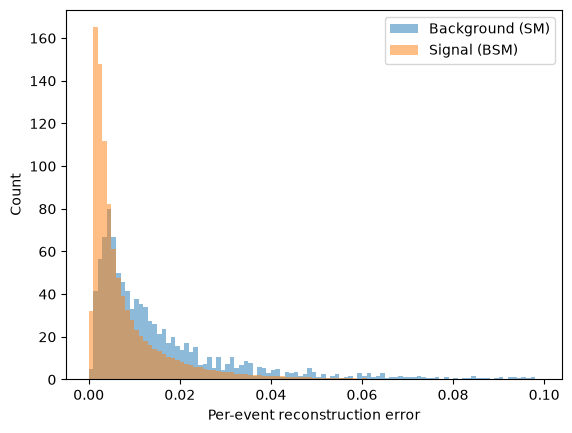

In [76]:
scores_bd = reconstruction_error(model, X_test)
scores_bsm = reconstruction_error(model, X_tensor_validate)

# Plot comparison on the same axis for clear anomaly detection visibility
plt.hist(scores_bd.cpu().numpy(), bins=np.arange(0, 0.1, 0.001), density=True, alpha=0.5, label='Background (SM)')
plt.hist(scores_bsm.cpu().numpy(), bins=np.arange(0, 0.1, 0.001), density=True, alpha=0.5, label='Signal (BSM)')
plt.xlabel("Per-event reconstruction error")
plt.ylabel("Count")
plt.legend(loc='upper right')
plt.show()